In [4]:
import pandas as pd
from pathlib import Path

registry_path = Path(r"C:\Data_analysis\Thesis\outputs\profile_forecasting\best_prediction_files_registry.csv")

best_prediction_registry = pd.read_csv(registry_path)

display(best_prediction_registry)

,registry_added_at,target_col,resolution,model_name,run_id,file_name,prediction_path,n_common_days,mean_actual_energy_kWh,mean_ml_predicted_energy_kWh,mean_constant_energy_kWh,mean_ml_absolute_energy_error_kWh,mean_ml_absolute_energy_error_percent,mean_constant_absolute_energy_error_kWh,mean_constant_absolute_energy_error_percent,mean_ml_improvement_vs_constant_percent
0,2026-05-29 13:43:08,BU_TotActPwr_Academy,15min,xgboost,run_20260512_171555_4d7cc794,run_20260512_171555_4d7cc794_xgboost_BU_TotAct...,C:\Data_analysis\Thesis\outputs\profile_foreca...,8,158.565797,158.376672,88.996980,29.558080,20.477633,74.282828,43.938212,29.744413
1,2026-05-29 13:43:08,BU_TotActPwr_Academy,30min,random_forest,run_20260526_154855_5f504912,run_20260526_154855_5f504912_random_forest_BU_...,C:\Data_analysis\Thesis\outputs\profile_foreca...,8,158.527170,178.946263,90.357030,38.487983,27.410292,72.994736,43.148351,-3.342269
2,2026-05-29 13:43:08,BU_TotActPwr_Academy,60min,random_forest,run_20260521_093016_89fcbb0f,run_20260521_093016_89fcbb0f_random_forest_BU_...,C:\Data_analysis\Thesis\outputs\profile_foreca...,8,158.515481,164.015870,88.651500,34.576039,25.591586,73.225176,43.307650,-2.266626
3,2026-05-29 13:43:29,BU_TotActPwr_SDB_EL_Substation,15min,random_forest,run_20260528_115442_63c0a563,run_20260528_115442_63c0a563_random_forest_BU_...,C:\Data_analysis\Thesis\outputs\profile_foreca...,9,81.565080,85.681771,109.140480,14.728917,18.065516,36.265066,44.529342,57.470873
4,2026-05-29 13:43:29,BU_TotActPwr_SDB_EL_Substation,30min,ridge,run_20260527_085838_bddbf081,run_20260527_085838_bddbf081_ridge_BU_TotActPw...,C:\Data_analysis\Thesis\outputs\profile_foreca...,9,81.652248,86.466756,107.838213,13.524637,16.614048,34.278122,41.859627,57.511177
5,2026-05-29 13:43:29,BU_TotActPwr_SDB_EL_Substation,60min,catboost,run_20260513_095636_ab78adf8,run_20260513_095636_ab78adf8_catboost_BU_TotAc...,C:\Data_analysis\Thesis\outputs\profile_foreca...,8,82.711270,87.022158,105.564510,10.635919,12.836926,30.822427,37.315588,65.138770
6,2026-05-29 13:43:18,BU_TotActPwr_Tech_Room,15min,random_forest,run_20260521_105037_ca9fc1b2,run_20260521_105037_ca9fc1b2_random_forest_BU_...,C:\Data_analysis\Thesis\outputs\profile_foreca...,9,58.106232,55.353108,90.743120,7.459176,12.808193,33.294782,57.338506,77.390772
7,2026-05-29 13:43:18,BU_TotActPwr_Tech_Room,30min,random_forest,run_20260527_102550_662ba0ff,run_20260527_102550_662ba0ff_random_forest_BU_...,C:\Data_analysis\Thesis\outputs\profile_foreca...,9,58.080091,55.520197,90.757307,6.898038,11.853753,33.223860,57.248999,79.056137
8,2026-05-29 13:43:18,BU_TotActPwr_Tech_Room,60min,xgboost,run_20260513_094936_b3ae2d0e,run_20260513_094936_b3ae2d0e_xgboost_BU_TotAct...,C:\Data_analysis\Thesis\outputs\profile_foreca...,9,58.073656,54.791928,90.179760,6.563000,11.283821,32.685582,56.331646,79.770657


In [5]:
selected_load = "BU_TotActPwr_Tech_Room"
selected_resolution = "15min"

selected_paths = best_prediction_registry[
    (best_prediction_registry["target_col"] == selected_load)
    & (best_prediction_registry["resolution"] == selected_resolution)
]["prediction_path"].tolist()

selected_paths

['C:\\Data_analysis\\Thesis\\outputs\\profile_forecasting\\predictions\\run_20260521_105037_ca9fc1b2_random_forest_BU_TotActPwr_Tech_Room_profile_predictions.csv']

In [6]:
selected_resolution = "15min"

paths_15min = best_prediction_registry[
    best_prediction_registry["resolution"] == selected_resolution
]["prediction_path"].tolist()

for p in paths_15min:
    print(p)

C:\Data_analysis\Thesis\outputs\profile_forecasting\predictions\run_20260512_171555_4d7cc794_xgboost_BU_TotActPwr_Academy_profile_predictions.csv
C:\Data_analysis\Thesis\outputs\profile_forecasting\predictions\run_20260528_115442_63c0a563_random_forest_BU_TotActPwr_SDB_EL_Substation_profile_predictions.csv
C:\Data_analysis\Thesis\outputs\profile_forecasting\predictions\run_20260521_105037_ca9fc1b2_random_forest_BU_TotActPwr_Tech_Room_profile_predictions.csv


In [8]:
from pathlib import Path
import pandas as pd
import numpy as np


# ============================================================
# SETTINGS
# ============================================================

registry_path = Path(
    r"C:\Data_analysis\Thesis\outputs\profile_forecasting\best_prediction_files_registry.csv"
)

target_cols = [
    "BU_TotActPwr_Academy",
    "BU_TotActPwr_SDB_EL_Substation",
    "BU_TotActPwr_Tech_Room",
]

resolutions = ["15min", "30min", "60min"]

dt_hours_map = {
    "15min": 0.25,
    "30min": 0.5,
    "60min": 1.0,
}

freq_map = {
    "15min": "15min",
    "30min": "30min",
    "60min": "60min",
}


# ============================================================
# LOAD REGISTRY
# ============================================================

registry = pd.read_csv(registry_path)

registry = registry[
    registry["target_col"].isin(target_cols)
    & registry["resolution"].isin(resolutions)
].copy()

display(registry[["target_col", "resolution", "model_name", "prediction_path"]])

,target_col,resolution,model_name,prediction_path
0,BU_TotActPwr_Academy,15min,xgboost,C:\Data_analysis\Thesis\outputs\profile_foreca...
1,BU_TotActPwr_Academy,30min,random_forest,C:\Data_analysis\Thesis\outputs\profile_foreca...
2,BU_TotActPwr_Academy,60min,random_forest,C:\Data_analysis\Thesis\outputs\profile_foreca...
3,BU_TotActPwr_SDB_EL_Substation,15min,random_forest,C:\Data_analysis\Thesis\outputs\profile_foreca...
4,BU_TotActPwr_SDB_EL_Substation,30min,ridge,C:\Data_analysis\Thesis\outputs\profile_foreca...
5,BU_TotActPwr_SDB_EL_Substation,60min,catboost,C:\Data_analysis\Thesis\outputs\profile_foreca...
6,BU_TotActPwr_Tech_Room,15min,random_forest,C:\Data_analysis\Thesis\outputs\profile_foreca...
7,BU_TotActPwr_Tech_Room,30min,random_forest,C:\Data_analysis\Thesis\outputs\profile_foreca...
8,BU_TotActPwr_Tech_Room,60min,xgboost,C:\Data_analysis\Thesis\outputs\profile_foreca...


In [9]:
def sort_horizon_columns(cols):
    def horizon_number(col):
        base = col.replace("_true", "").replace("_pred", "")
        nums = [p for p in base.split("_") if p.isdigit()]
        return int(nums[-1]) if nums else 999999

    return sorted(cols, key=horizon_number)


def read_prediction_file_long(row):
    file_path = Path(row["prediction_path"])
    target_col = row["target_col"]
    resolution = row["resolution"]
    model_name = row["model_name"]

    dt_hours = dt_hours_map[resolution]
    freq = freq_map[resolution]

    df = pd.read_csv(file_path)

    df = df.rename(columns={df.columns[0]: "issue_time"})
    df["issue_time"] = pd.to_datetime(df["issue_time"], errors="coerce")
    df = df.dropna(subset=["issue_time"]).copy()

    true_cols = sort_horizon_columns([c for c in df.columns if c.endswith("_true")])
    pred_cols = [c.replace("_true", "_pred") for c in true_cols]

    rows = []

    for _, r in df.iterrows():
        issue_time = r["issue_time"]
        forecast_date = (issue_time + pd.Timedelta(days=1)).date()

        y_true = pd.to_numeric(r[true_cols], errors="coerce").to_numpy(dtype=float)
        y_pred = pd.to_numeric(r[pred_cols], errors="coerce").to_numpy(dtype=float)

        constant_load = y_true[0]
        y_constant = np.full_like(y_true, constant_load, dtype=float)

        valid = ~(np.isnan(y_true) | np.isnan(y_pred) | np.isnan(y_constant))

        y_true = y_true[valid]
        y_pred = y_pred[valid]
        y_constant = y_constant[valid]

        horizon_times = pd.date_range(
            start=issue_time + pd.Timedelta(hours=dt_hours),
            periods=len(y_true),
            freq=freq,
        )

        temp = pd.DataFrame({
            "target_col": target_col,
            "resolution": resolution,
            "model_name": model_name,
            "issue_time": issue_time,
            "forecast_date": forecast_date,
            "time": horizon_times,
            "actual_load_kW": y_true,
            "ml_predicted_load_kW": y_pred,
            "constant_load_kW": y_constant,
        })

        rows.append(temp)

    return pd.concat(rows, ignore_index=True)

In [10]:
all_load_prediction_long = []

for _, row in registry.iterrows():
    df_long = read_prediction_file_long(row)
    all_load_prediction_long.append(df_long)

all_load_prediction_long = pd.concat(all_load_prediction_long, ignore_index=True)

display(all_load_prediction_long.head())

,target_col,resolution,model_name,issue_time,forecast_date,time,actual_load_kW,ml_predicted_load_kW,constant_load_kW
0,BU_TotActPwr_Academy,15min,xgboost,2026-04-19 23:45:00,2026-04-20,2026-04-20 00:00:00,3.60833,4.038613,3.60833
1,BU_TotActPwr_Academy,15min,xgboost,2026-04-19 23:45:00,2026-04-20,2026-04-20 00:15:00,3.89500,4.455495,3.60833
2,BU_TotActPwr_Academy,15min,xgboost,2026-04-19 23:45:00,2026-04-20,2026-04-20 00:30:00,3.66933,3.349842,3.60833
3,BU_TotActPwr_Academy,15min,xgboost,2026-04-19 23:45:00,2026-04-20,2026-04-20 00:45:00,3.47033,3.558782,3.60833
4,BU_TotActPwr_Academy,15min,xgboost,2026-04-19 23:45:00,2026-04-20,2026-04-20 01:00:00,3.34033,3.082543,3.60833


In [11]:
valid_dates_per_resolution = {}

for resolution in resolutions:
    temp = all_load_prediction_long[
        all_load_prediction_long["resolution"] == resolution
    ]

    load_count_by_date = (
        temp.groupby("forecast_date")["target_col"]
        .nunique()
    )

    common_dates = load_count_by_date[
        load_count_by_date == len(target_cols)
    ].index

    valid_dates_per_resolution[resolution] = set(common_dates)

    print(resolution, "common dates:", len(common_dates))

15min common dates: 7
30min common dates: 9
60min common dates: 8


In [12]:
filtered_long = []

for resolution in resolutions:
    temp = all_load_prediction_long[
        (all_load_prediction_long["resolution"] == resolution)
        & (all_load_prediction_long["forecast_date"].isin(valid_dates_per_resolution[resolution]))
    ].copy()

    filtered_long.append(temp)

filtered_long = pd.concat(filtered_long, ignore_index=True)


total_load_by_resolution = (
    filtered_long
    .groupby(["resolution", "forecast_date", "time"], as_index=False)
    .agg(
        total_actual_load_kW=("actual_load_kW", "sum"),
        total_ml_predicted_load_kW=("ml_predicted_load_kW", "sum"),
        total_constant_load_kW=("constant_load_kW", "sum"),
        n_loads=("target_col", "nunique"),
    )
)

# Safety check: keep only rows where all 3 loads were added
total_load_by_resolution = total_load_by_resolution[
    total_load_by_resolution["n_loads"] == len(target_cols)
].copy()

display(total_load_by_resolution.head())

,resolution,forecast_date,time,total_actual_load_kW,total_ml_predicted_load_kW,total_constant_load_kW,n_loads
0,15min,2026-04-23,2026-04-23 00:00:00,11.30700,11.184935,11.307,3
1,15min,2026-04-23,2026-04-23 00:15:00,11.02333,11.800314,11.307,3
2,15min,2026-04-23,2026-04-23 00:30:00,11.70167,11.132166,11.307,3
3,15min,2026-04-23,2026-04-23 00:45:00,10.83033,10.379990,11.307,3
4,15min,2026-04-23,2026-04-23 01:00:00,10.67867,9.888003,11.307,3


In [13]:
energy_rows = []

for resolution in resolutions:
    dt_hours = dt_hours_map[resolution]

    temp = total_load_by_resolution[
        total_load_by_resolution["resolution"] == resolution
    ].copy()

    daily = (
        temp.groupby(["resolution", "forecast_date"], as_index=False)
        .agg(
            actual_energy_kWh=("total_actual_load_kW", lambda x: np.sum(x * dt_hours)),
            ml_predicted_energy_kWh=("total_ml_predicted_load_kW", lambda x: np.sum(x * dt_hours)),
            constant_energy_kWh=("total_constant_load_kW", lambda x: np.sum(x * dt_hours)),
        )
    )

    daily["ml_signed_energy_error_kWh"] = (
        daily["actual_energy_kWh"] - daily["ml_predicted_energy_kWh"]
    )

    daily["constant_signed_energy_error_kWh"] = (
        daily["actual_energy_kWh"] - daily["constant_energy_kWh"]
    )

    daily["ml_absolute_energy_error_kWh"] = (
        daily["actual_energy_kWh"] - daily["ml_predicted_energy_kWh"]
    ).abs()

    daily["constant_absolute_energy_error_kWh"] = (
        daily["actual_energy_kWh"] - daily["constant_energy_kWh"]
    ).abs()

    daily["ml_absolute_energy_error_%"] = (
        daily["ml_absolute_energy_error_kWh"] / daily["actual_energy_kWh"] * 100
    )

    daily["constant_absolute_energy_error_%"] = (
        daily["constant_absolute_energy_error_kWh"] / daily["actual_energy_kWh"] * 100
    )

    daily["ml_improvement_vs_constant_kWh"] = (
        daily["constant_absolute_energy_error_kWh"]
        - daily["ml_absolute_energy_error_kWh"]
    )

    daily["ml_improvement_vs_constant_%"] = (
        daily["ml_improvement_vs_constant_kWh"]
        / daily["constant_absolute_energy_error_kWh"]
        * 100
    )

    energy_rows.append(daily)

total_energy_error_by_resolution = pd.concat(energy_rows, ignore_index=True)

display(total_energy_error_by_resolution)

,resolution,forecast_date,actual_energy_kWh,ml_predicted_energy_kWh,constant_energy_kWh,ml_signed_energy_error_kWh,constant_signed_energy_error_kWh,ml_absolute_energy_error_kWh,constant_absolute_energy_error_kWh,ml_absolute_energy_error_%,constant_absolute_energy_error_%,ml_improvement_vs_constant_kWh,ml_improvement_vs_constant_%
0,15min,2026-04-23,311.628445,297.167471,271.36800,14.460974,40.260445,14.460974,40.260445,4.640454,12.919374,25.799471,64.081435
1,15min,2026-04-24,318.219225,304.393418,313.92792,13.825807,4.291305,13.825807,4.291305,4.344743,1.348537,-9.534502,-222.181875
2,15min,2026-04-25,253.641112,282.410036,292.72800,-28.768923,-39.086888,28.768923,39.086888,11.342374,15.410312,10.317964,26.397508
3,15min,2026-04-26,246.542757,272.660039,285.52800,-26.117281,-38.985243,26.117281,38.985243,10.593408,15.812771,12.867961,33.007262
4,15min,2026-04-27,324.394910,299.359979,307.28808,25.034931,17.106830,25.034931,17.106830,7.717424,5.273458,-7.928101,-46.344652
5,15min,2026-04-28,310.186420,324.165753,262.60008,-13.979333,47.586340,13.979333,47.586340,4.506752,15.341207,33.607007,70.623223
6,15min,2026-04-29,319.712000,317.532480,306.04800,2.179520,13.664000,2.179520,13.664000,0.681714,4.273846,11.484480,84.049181
7,30min,2026-04-22,297.574620,336.487972,271.39176,-38.913352,26.182860,38.913352,26.182860,13.076838,8.798754,-12.730492,-48.621473
8,30min,2026-04-23,311.416700,305.315747,267.96408,6.100953,43.452620,6.100953,43.452620,1.959096,13.953208,37.351667,85.959528
9,30min,2026-04-24,318.226205,323.441098,319.17984,-5.214893,-0.953635,5.214893,0.953635,1.638738,0.299672,-4.261258,-446.843703


In [14]:
total_energy_summary = (
    total_energy_error_by_resolution
    .groupby("resolution", as_index=False)
    .agg(
        n_days=("forecast_date", "nunique"),

        mean_actual_energy_kWh=("actual_energy_kWh", "mean"),
        mean_ml_predicted_energy_kWh=("ml_predicted_energy_kWh", "mean"),
        mean_constant_energy_kWh=("constant_energy_kWh", "mean"),

        mean_ml_signed_energy_error_kWh=("ml_signed_energy_error_kWh", "mean"),
        mean_constant_signed_energy_error_kWh=("constant_signed_energy_error_kWh", "mean"),

        mean_ml_absolute_energy_error_kWh=("ml_absolute_energy_error_kWh", "mean"),
        mean_ml_absolute_energy_error_percent=("ml_absolute_energy_error_%", "mean"),

        mean_constant_absolute_energy_error_kWh=("constant_absolute_energy_error_kWh", "mean"),
        mean_constant_absolute_energy_error_percent=("constant_absolute_energy_error_%", "mean"),

        mean_ml_improvement_vs_constant_kWh=("ml_improvement_vs_constant_kWh", "mean"),
        mean_ml_improvement_vs_constant_percent=("ml_improvement_vs_constant_%", "mean"),
    )
)

resolution_order = {"15min": 0, "30min": 1, "60min": 2}
total_energy_summary["resolution_order"] = total_energy_summary["resolution"].map(resolution_order)

total_energy_summary = (
    total_energy_summary
    .sort_values("resolution_order")
    .drop(columns="resolution_order")
    .reset_index(drop=True)
)

display(total_energy_summary)

,resolution,n_days,mean_actual_energy_kWh,mean_ml_predicted_energy_kWh,mean_constant_energy_kWh,mean_ml_signed_energy_error_kWh,mean_constant_signed_energy_error_kWh,mean_ml_absolute_energy_error_kWh,mean_ml_absolute_energy_error_percent,mean_constant_absolute_energy_error_kWh,mean_constant_absolute_energy_error_percent,mean_ml_improvement_vs_constant_kWh,mean_ml_improvement_vs_constant_percent
0,15min,7,297.760696,299.669882,291.355440,-1.909186,6.405256,17.766681,6.260981,28.711579,10.054215,10.944897,1.376012
1,30min,9,297.278578,322.757922,288.400853,-25.479343,8.877725,26.835111,9.721050,25.902367,9.032687,-0.932744,-59.460850
2,60min,8,297.262036,309.307234,284.450250,-12.045198,12.811786,27.215092,9.883262,32.105286,11.016724,4.890194,8.161116


In [15]:
required_resolutions = {"15min", "30min", "60min"}

available_resolutions_by_date = (
    total_energy_error_by_resolution
    .groupby("forecast_date")["resolution"]
    .apply(set)
)

common_dates_total = available_resolutions_by_date[
    available_resolutions_by_date.apply(lambda x: required_resolutions.issubset(x))
].index

print("Common dates across all resolutions:", len(common_dates_total))
print(list(common_dates_total))

Common dates across all resolutions: 7
[datetime.date(2026, 4, 23), datetime.date(2026, 4, 24), datetime.date(2026, 4, 25), datetime.date(2026, 4, 26), datetime.date(2026, 4, 27), datetime.date(2026, 4, 28), datetime.date(2026, 4, 29)]


In [16]:
total_energy_error_common_dates = total_energy_error_by_resolution[
    total_energy_error_by_resolution["forecast_date"].isin(common_dates_total)
    & total_energy_error_by_resolution["resolution"].isin(required_resolutions)
].copy()

display(
    total_energy_error_common_dates
    .sort_values(["forecast_date", "resolution"])
)

,resolution,forecast_date,actual_energy_kWh,ml_predicted_energy_kWh,constant_energy_kWh,ml_signed_energy_error_kWh,constant_signed_energy_error_kWh,ml_absolute_energy_error_kWh,constant_absolute_energy_error_kWh,ml_absolute_energy_error_%,constant_absolute_energy_error_%,ml_improvement_vs_constant_kWh,ml_improvement_vs_constant_%
0,15min,2026-04-23,311.628445,297.167471,271.36800,14.460974,40.260445,14.460974,40.260445,4.640454,12.919374,25.799471,64.081435
8,30min,2026-04-23,311.416700,305.315747,267.96408,6.100953,43.452620,6.100953,43.452620,1.959096,13.953208,37.351667,85.959528
16,60min,2026-04-23,311.322740,304.193217,269.17392,7.129523,42.148820,7.129523,42.148820,2.290075,13.538626,35.019297,83.084881
1,15min,2026-04-24,318.219225,304.393418,313.92792,13.825807,4.291305,13.825807,4.291305,4.344743,1.348537,-9.534502,-222.181875
9,30min,2026-04-24,318.226205,323.441098,319.17984,-5.214893,-0.953635,5.214893,0.953635,1.638738,0.299672,-4.261258,-446.843703
17,60min,2026-04-24,318.310950,312.854230,295.91976,5.456720,22.391190,5.456720,22.391190,1.714274,7.034376,16.934470,75.630057
2,15min,2026-04-25,253.641112,282.410036,292.72800,-28.768923,-39.086888,28.768923,39.086888,11.342374,15.410312,10.317964,26.397508
10,30min,2026-04-25,253.651920,304.289148,283.23216,-50.637228,-29.580240,50.637228,29.580240,19.963274,11.661745,-21.056988,-71.185993
18,60min,2026-04-25,253.695680,303.423646,286.73616,-49.727966,-33.040480,49.727966,33.040480,19.601424,13.023667,-16.687486,-50.506184
3,15min,2026-04-26,246.542757,272.660039,285.52800,-26.117281,-38.985243,26.117281,38.985243,10.593408,15.812771,12.867961,33.007262


In [17]:
common_date_check = (
    total_energy_error_common_dates
    .groupby("forecast_date")["resolution"]
    .apply(lambda x: sorted(x.unique()))
    .reset_index()
)

display(common_date_check)

,forecast_date,resolution
0,2026-04-23,"[15min, 30min, 60min]"
1,2026-04-24,"[15min, 30min, 60min]"
2,2026-04-25,"[15min, 30min, 60min]"
3,2026-04-26,"[15min, 30min, 60min]"
4,2026-04-27,"[15min, 30min, 60min]"
5,2026-04-28,"[15min, 30min, 60min]"
6,2026-04-29,"[15min, 30min, 60min]"


In [18]:
total_energy_summary_common_dates = (
    total_energy_error_common_dates
    .groupby("resolution", as_index=False)
    .agg(
        n_common_days=("forecast_date", "nunique"),

        mean_actual_energy_kWh=("actual_energy_kWh", "mean"),
        mean_ml_predicted_energy_kWh=("ml_predicted_energy_kWh", "mean"),
        mean_constant_energy_kWh=("constant_energy_kWh", "mean"),

        mean_ml_signed_energy_error_kWh=("ml_signed_energy_error_kWh", "mean"),
        mean_constant_signed_energy_error_kWh=("constant_signed_energy_error_kWh", "mean"),

        mean_ml_absolute_energy_error_kWh=("ml_absolute_energy_error_kWh", "mean"),
        mean_ml_absolute_energy_error_percent=("ml_absolute_energy_error_%", "mean"),

        mean_constant_absolute_energy_error_kWh=("constant_absolute_energy_error_kWh", "mean"),
        mean_constant_absolute_energy_error_percent=("constant_absolute_energy_error_%", "mean"),

        mean_ml_improvement_vs_constant_kWh=("ml_improvement_vs_constant_kWh", "mean"),
        mean_ml_improvement_vs_constant_percent=("ml_improvement_vs_constant_%", "mean"),
    )
)

resolution_order = {"15min": 0, "30min": 1, "60min": 2}

total_energy_summary_common_dates["resolution_order"] = (
    total_energy_summary_common_dates["resolution"].map(resolution_order)
)

total_energy_summary_common_dates = (
    total_energy_summary_common_dates
    .sort_values("resolution_order")
    .drop(columns="resolution_order")
    .reset_index(drop=True)
)

display(total_energy_summary_common_dates)

,resolution,n_common_days,mean_actual_energy_kWh,mean_ml_predicted_energy_kWh,mean_constant_energy_kWh,mean_ml_signed_energy_error_kWh,mean_constant_signed_energy_error_kWh,mean_ml_absolute_energy_error_kWh,mean_ml_absolute_energy_error_percent,mean_constant_absolute_energy_error_kWh,mean_constant_absolute_energy_error_percent,mean_ml_improvement_vs_constant_kWh,mean_ml_improvement_vs_constant_percent
0,15min,7,297.760696,299.669882,291.355440,-1.909186,6.405256,17.766681,6.260981,28.711579,10.054215,10.944897,1.376012
1,30min,7,297.724106,321.036563,291.834857,-23.312456,5.889249,25.055586,9.307430,27.778075,9.749215,2.722489,-52.668141
2,60min,7,297.721310,307.950501,284.890869,-10.229191,12.830441,27.566213,10.092373,34.880156,11.974449,7.313942,22.930980


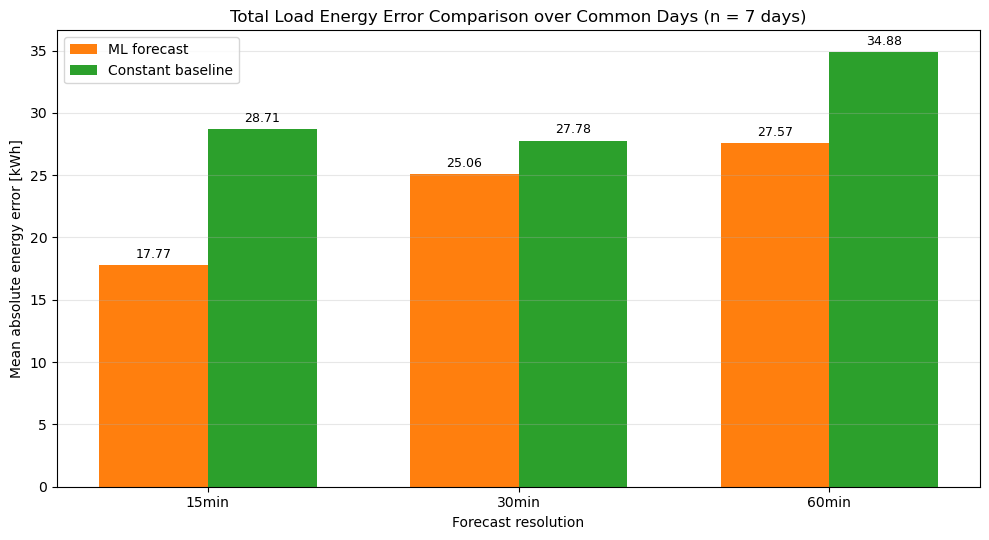

In [19]:
import numpy as np
import matplotlib.pyplot as plt


def add_bar_labels(ax, fmt="{:.2f}"):
    for container in ax.containers:
        ax.bar_label(container, fmt=fmt, padding=3, fontsize=9)


plot_df = total_energy_summary_common_dates.copy()

resolution_order = {"15min": 0, "30min": 1, "60min": 2}
plot_df["resolution_order"] = plot_df["resolution"].map(resolution_order)
plot_df = plot_df.sort_values("resolution_order").reset_index(drop=True)

x = np.arange(len(plot_df))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5.5))

ax.bar(
    x - width / 2,
    plot_df["mean_ml_absolute_energy_error_kWh"],
    width,
    label="ML forecast",
    color="tab:orange"
)

ax.bar(
    x + width / 2,
    plot_df["mean_constant_absolute_energy_error_kWh"],
    width,
    label="Constant baseline",
    color="tab:green"
)

ax.set_xticks(x)
ax.set_xticklabels(plot_df["resolution"])

ax.set_ylabel("Mean absolute energy error [kWh]")
ax.set_xlabel("Forecast resolution")
ax.set_title(
    f"Total Load Energy Error Comparison over Common Days "
    f"(n = {plot_df['n_common_days'].iloc[0]} days)"
)

ax.grid(axis="y", alpha=0.3)
ax.legend()

add_bar_labels(ax, fmt="{:.2f}")

plt.tight_layout()
plt.show()

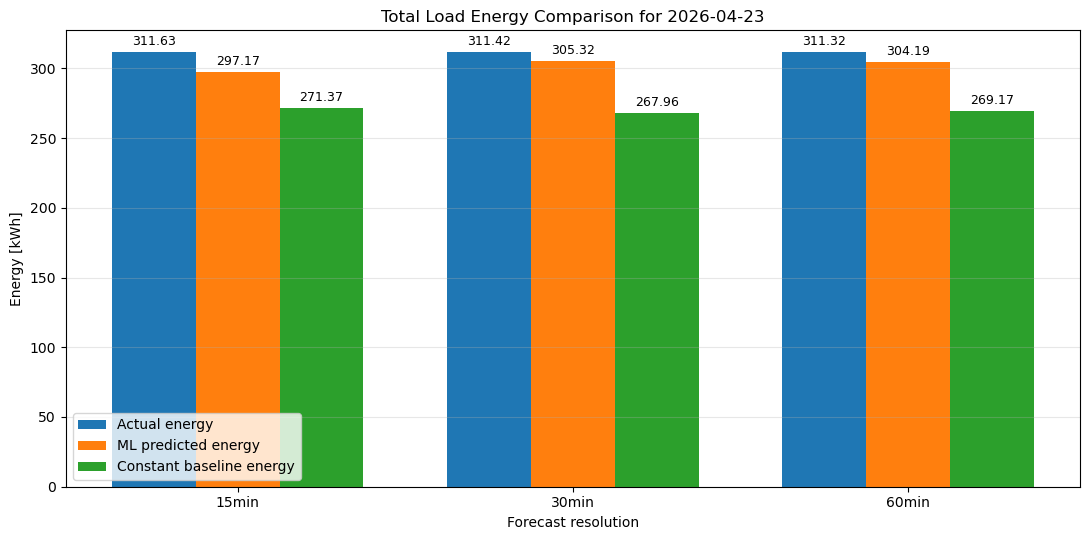

In [21]:
selected_day = "2026-04-23"

energy_day_df = total_energy_error_common_dates[
    total_energy_error_common_dates["forecast_date"] == pd.to_datetime(selected_day).date()
].copy()

energy_day_df["resolution_order"] = energy_day_df["resolution"].map(resolution_order)
energy_day_df = energy_day_df.sort_values("resolution_order").reset_index(drop=True)

x = np.arange(len(energy_day_df))
width = 0.25

fig, ax = plt.subplots(figsize=(11, 5.5))

ax.bar(
    x - width,
    energy_day_df["actual_energy_kWh"],
    width,
    label="Actual energy",
    color="tab:blue"
)

ax.bar(
    x,
    energy_day_df["ml_predicted_energy_kWh"],
    width,
    label="ML predicted energy",
    color="tab:orange"
)

ax.bar(
    x + width,
    energy_day_df["constant_energy_kWh"],
    width,
    label="Constant baseline energy",
    color="tab:green"
)

ax.set_xticks(x)
ax.set_xticklabels(energy_day_df["resolution"])

ax.set_ylabel("Energy [kWh]")
ax.set_xlabel("Forecast resolution")
ax.set_title(f"Total Load Energy Comparison for {selected_day}")

ax.grid(axis="y", alpha=0.3)
ax.legend()

add_bar_labels(ax, fmt="{:.2f}")

plt.tight_layout()
plt.show()

In [22]:
import pandas as pd
import matplotlib.pyplot as plt


selected_day = "2026-04-23"

plot_day = pd.to_datetime(selected_day).date()

plot_df = total_load_by_resolution[
    total_load_by_resolution["forecast_date"] == plot_day
].copy()

resolution_order = {"15min": 0, "30min": 1, "60min": 2}
plot_df["resolution_order"] = plot_df["resolution"].map(resolution_order)

plot_df = plot_df.sort_values(["resolution_order", "time"]).reset_index(drop=True)

display(plot_df.head())

,resolution,forecast_date,time,total_actual_load_kW,total_ml_predicted_load_kW,total_constant_load_kW,n_loads,resolution_order
0,15min,2026-04-23,2026-04-23 00:00:00,11.30700,11.184935,11.307,3,0
1,15min,2026-04-23,2026-04-23 00:15:00,11.02333,11.800314,11.307,3,0
2,15min,2026-04-23,2026-04-23 00:30:00,11.70167,11.132166,11.307,3,0
3,15min,2026-04-23,2026-04-23 00:45:00,10.83033,10.379990,11.307,3,0
4,15min,2026-04-23,2026-04-23 01:00:00,10.67867,9.888003,11.307,3,0


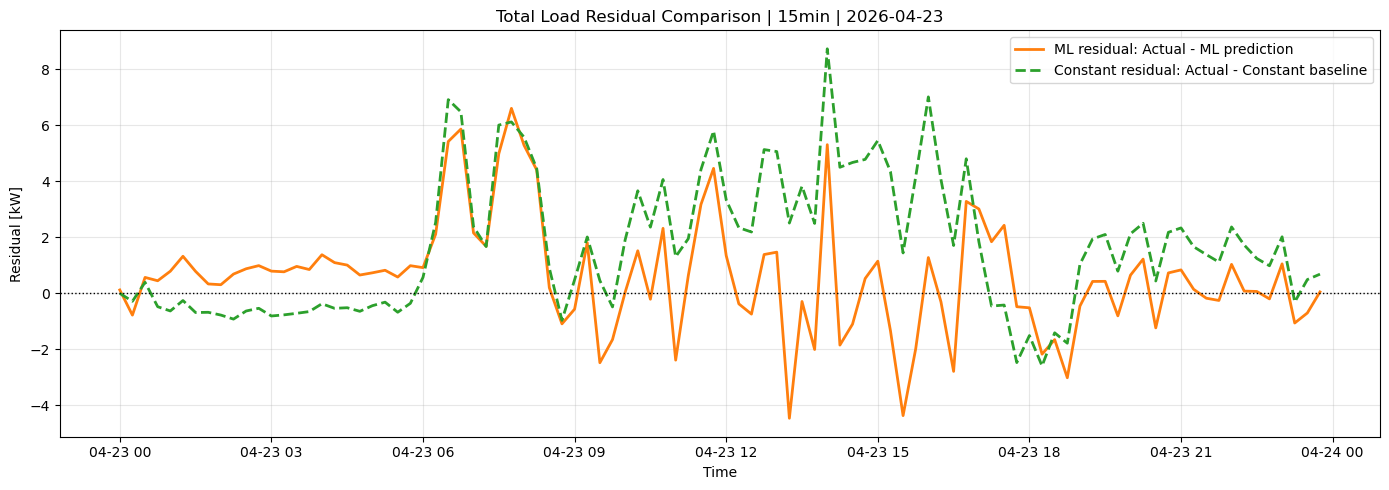

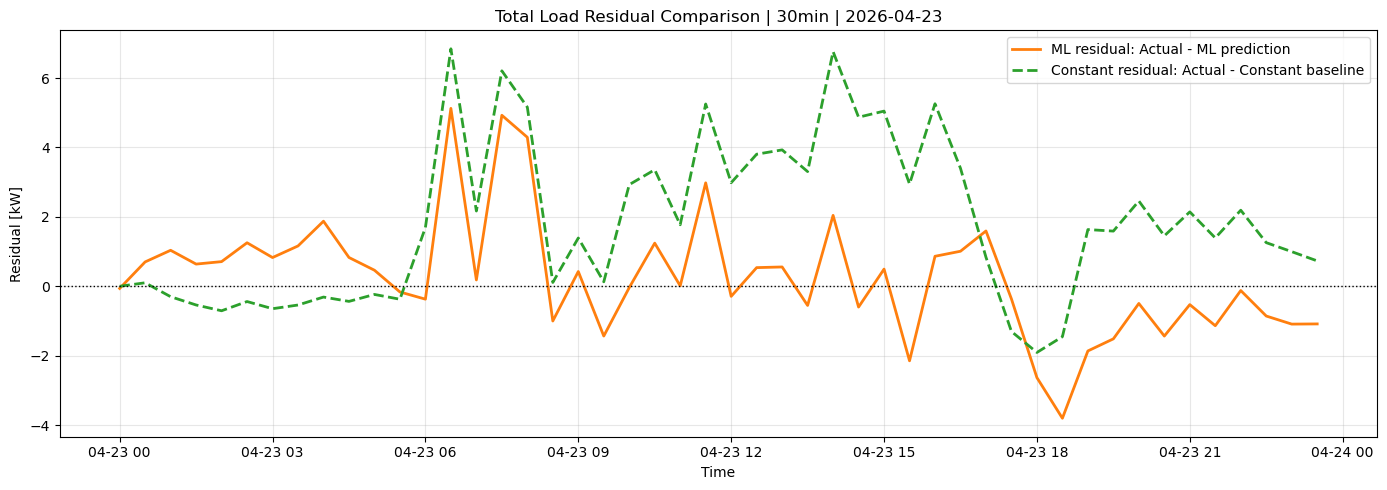

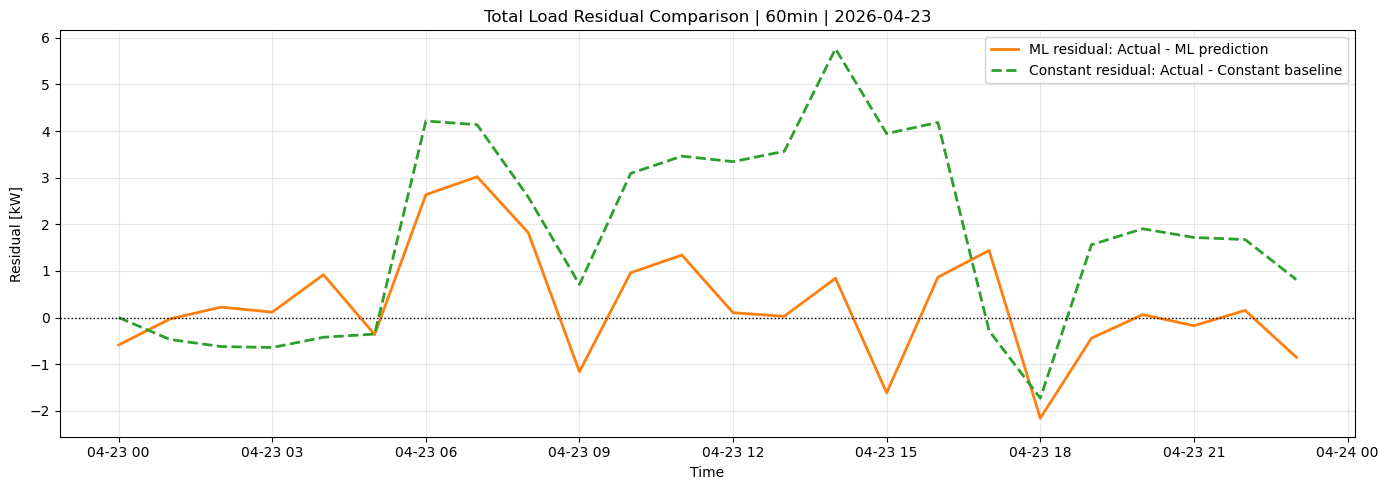

In [23]:
actual_color = "tab:blue"
ml_color = "tab:orange"
constant_color = "tab:green"


for resolution in ["15min", "30min", "60min"]:

    temp = plot_df[plot_df["resolution"] == resolution].copy()

    if temp.empty:
        print(f"No data found for {selected_day} and {resolution}")
        continue

    temp["ml_residual_kW"] = (
        temp["total_actual_load_kW"] - temp["total_ml_predicted_load_kW"]
    )

    temp["constant_residual_kW"] = (
        temp["total_actual_load_kW"] - temp["total_constant_load_kW"]
    )

    plt.figure(figsize=(14, 5))

    plt.plot(
        temp["time"],
        temp["ml_residual_kW"],
        label="ML residual: Actual - ML prediction",
        color=ml_color,
        linewidth=2
    )

    plt.plot(
        temp["time"],
        temp["constant_residual_kW"],
        label="Constant residual: Actual - Constant baseline",
        color=constant_color,
        linewidth=2,
        linestyle="--"
    )

    plt.axhline(
        0,
        color="black",
        linestyle=":",
        linewidth=1
    )

    plt.title(
        f"Total Load Residual Comparison | {resolution} | {selected_day}"
    )

    plt.xlabel("Time")
    plt.ylabel("Residual [kW]")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()